# Model and Wrapper

## Model

In [1]:
from torch import nn
from typing import Literal

class MLPClassifier(nn.Module):
    def __init__(self, n_hidden:int, hidden_dim:int, input_dim:int, output_dim:int, activation:Literal['ReLU', 'Tanh'] = 'ReLU'):
        super(MLPClassifier, self).__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)])
        self.output_layer = nn.Linear(hidden_dim, output_dim)

        if activation == 'ReLU':
            self.activation = nn.ReLU()
        elif activation == 'Tanh':
            self.activation = nn.Tanh()
        else:
            raise ValueError(f"Unknown activation function: {activation}")

    def forward(self, input):
        x = self.activation(self.input_layer(input))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.output_layer(x)

        return x.squeeze(1) if x.shape[-1] == 1 else x

## Wrapper

In [2]:
import numpy as np
from torch.nn.utils import clip_grad_norm_
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import accuracy_score

class MyWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, model, classes:list | np.ndarray, lr:float=1e-3, epochs:int=50, batch_size:int=None, device:torch.device=None, is_fitted:bool = False):
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = device

        self.model = model.to(self.device)
        self.classes = classes
        self.classes_ = classes

        self.batch_size = batch_size
        self.epochs = epochs
        self.lr = lr
        self.is_fitted  = is_fitted


    def fit(self, X: np.ndarray, y: np.ndarray, sample_weight=None) -> float:
        def _train_one_epoch(model, loader, optimizer, criterion, max_norm:float=1.0):
            model.train()
            running_loss = 0.0
            for X, y in loader:
                X, y = X.to(self.device), y.to(self.device)
                optimizer.zero_grad()
                loss = criterion(model(X), y)
                running_loss += loss.item()
                loss.backward()
                clip_grad_norm_(model.parameters(), max_norm=max_norm)
                optimizer.step()
            avg_loss = running_loss / len(loader)

            return avg_loss

        self.model.to(self.device)
        optimzer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        if len(self.classes) == 2:
            criterion = nn.BCEWithLogitsLoss()
            y_tensor = torch.Tensor(y).to(self.device)

        else:
            criterion = nn.CrossEntropyLoss()
            y_tensor = torch.Tensor(y).long().to(self.device)

        X_tensor = torch.Tensor(X).to(self.device)

        if sample_weight is not None:
            sampler = WeightedRandomSampler(sample_weight, len(X_tensor), replacement=True)
        else:
            sampler = None

        train_loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=self.batch_size, sampler=sampler)

        running_loss = 0.0
        for epoch in range(self.epochs):
            running_loss += _train_one_epoch(self.model, train_loader, optimzer, criterion)

        print(f'Avrage Loss {running_loss/self.epochs}')

        self.is_fitted = True
        return self


    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X_tensor = torch.Tensor(X).to(self.device)

        self.model.eval()
        output = self.model(X_tensor)

        if len(self.classes) == 2:
            proba = torch.sigmoid(output).detach().cpu().numpy()
            proba = proba.reshape(-1, 1)
            proba = np.hstack([1 - proba, proba])
        else:
            proba = torch.softmax(output, dim=1).detach().cpu().numpy()


        return proba

    def predict(self, X: np.ndarray) -> np.ndarray:
        proba = self.predict_proba(X)

        if len(self.classes) == 2:
            preds = self.classes[(proba[:, 1] >= 0.5).astype(int)]
        else:
            preds = self.classes[proba.argmax(axis=1)]

        return preds


    def score(self, X, y, sample_weight=None):
        check_is_fitted(self, attributes=["is_fitted"])
        y_pred = self.predict(X)

        return accuracy_score(y, y_pred, sample_weight=sample_weight)


# Data

In [3]:
import openml
import warnings

# Suppress all FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)

dataset = openml.datasets.get_dataset(46880)

X, y, categorical_indicator, attribute_names = dataset.get_data(
    dataset_format="dataframe",
    target=dataset.default_target_attribute,
)


print(dataset)
print(f"data shape: {X.shape}")
print(f"name features: {y.nunique()}")
X.head()

OpenML Dataset
Name..........: air-quality-and-pollution-assessment
Version.......: 2
Format........: arff
Upload Date...: 2025-04-14 14:41:44
Licence.......: Kaggle, Apache 2.0
Download URL..: https://openml.org/data/v1/download/22124444/air-quality-and-pollution-assessment.arff
OpenML URL....: https://www.openml.org/d/46880
# of features.: 10
# of instances: 5000
data shape: (5000, 9)
name features: 4


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

map_dict = {"Good": 0, "Hazardous": 1, "Moderate": 2, "Poor": 3}
y = y.map(map_dict)

X = X.to_numpy()
y = y.to_numpy()

X_train_val_cal, X_test, y_train_val_cal, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
X_train_val, X_cal, y_train_val, y_cal = train_test_split(X_train_val_cal, y_train_val_cal, test_size=0.2, random_state=42, stratify=y_train_val_cal)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val)

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_cal = scaler.transform(X_cal)
X_test = scaler.transform(X_test)


print(f"Training set size: {len(y_train)}\n"
      f"Val set size: {len(y_val)}\n"
      f"Calibration set size: {len(y_cal)}\n"
      f"Test set size: {len(y_test)}")

Training set size: 2880
Val set size: 720
Calibration set size: 900
Test set size: 500


# Training

In [31]:
from sklearn.utils import compute_class_weight
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_score

classes = np.unique(y_train)
model_parameter = {
    'n_hidden': 3,
    'hidden_dim': 64,
    'input_dim':X_train_val.shape[1],
    'output_dim': len(classes)
}

model = MLPClassifier(**model_parameter)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
clf = MyWrapper(model=model, classes=classes, epochs=5, batch_size=32, lr=1e-3)

clf.fit(X_train, y_train.astype(np.int64), sample_weight=weights)
y_pred = clf.predict(X_val)
scores = cross_val_score(clf, X_val, y_val, cv=5)
print(confusion_matrix(y_val, y_pred))
print(accuracy_score(y_val, y_pred))
print(scores)

Avrage Loss 0.1206266390978514
Avrage Loss 1.2913769693010384
Avrage Loss 1.2938665391670334
Avrage Loss 1.2775727168553406
Avrage Loss 1.2390914366477064
Avrage Loss 1.2449601236316892
[[  0   0  74 214]
 [  0   3  11  58]
 [  0   0 120  96]
 [  0   2  55  87]]
0.2916666666666667
[0.86111111 0.90972222 0.89583333 0.85416667 0.89583333]


# Calibration

Avrage Loss 1.0681312377038208
Avrage Loss 1.0379611547874368
Avrage Loss 1.0562310511003372
Avrage Loss 1.069817443386368
Avrage Loss 1.0505036151927452


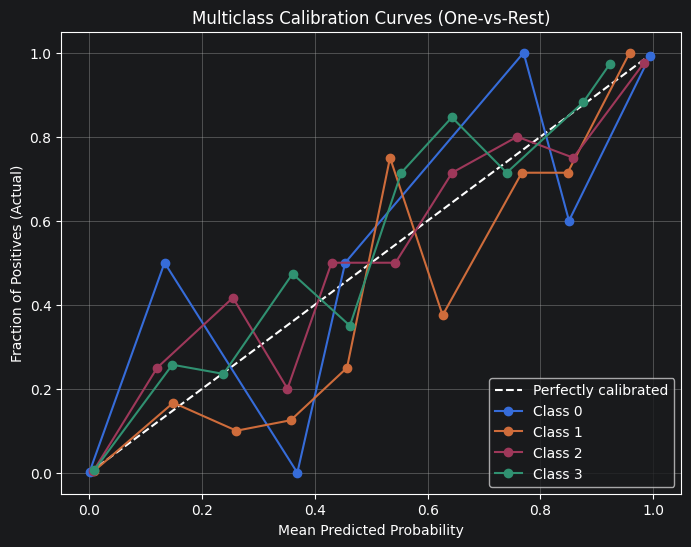

In [32]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

#calibrated_clf = CalibratedClassifierCV(clf, method='sigmoid')
calibrated_clf = CalibratedClassifierCV(clf, method='isotonic')
# calibrated_clf = CalibratedClassifierCV(clf,method='temperature')
calibrated_clf.fit(X_cal, y_cal)

# skalowanie metodą ‘ temperature’ jest dostepne od wersji scikit-learn 1.8.0
init_probs = clf.predict_proba(X_val)
calibrated_probs = calibrated_clf.predict_proba(X_val)
y_true = y_val

# --- 2. PLOT THE CALIBRATION CURVE FOR EACH CLASS ---
plt.figure(figsize=(8, 6))

# Plot the diagonal reference line (Perfect Calibration)
plt.plot([0, 1], [0, 1], "w--", label="Perfectly calibrated")

# Loop through each of your 4 classes
for class_idx in range(4):
    # Convert multi-class labels into binary labels for the current class
    y_true_binary = (y_true == class_idx).astype(int)

    # Extract the predicted probabilities for the current class
    y_prob_class = calibrated_probs[:, class_idx]

    # Calculate calibration curve
    # n_bins=5 to 10 is usually standard depending on your dataset size
    prob_true, prob_pred = calibration_curve(
        y_true_binary, y_prob_class, n_bins=10, strategy="uniform"
    )

    # Plot the curve for this specific class
    plt.plot(
        prob_pred, prob_true, marker="o", label=f"Class {class_idx}"
    )

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives (Actual)")
plt.title("Multiclass Calibration Curves (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Testing
It is clear to see that after calibration the model performs way better

======== AFTER CALIBRATION ========



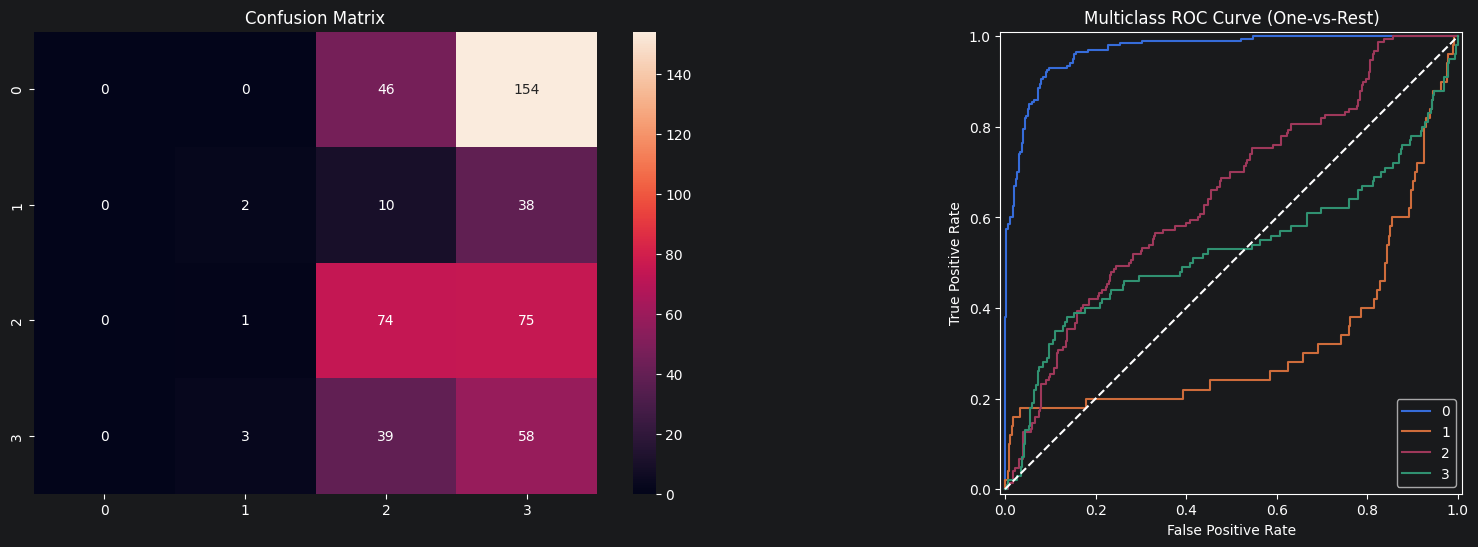

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       200
           1       0.33      0.04      0.07        50
           2       0.44      0.49      0.46       150
           3       0.18      0.58      0.27       100

    accuracy                           0.27       500
   macro avg       0.24      0.28      0.20       500
weighted avg       0.20      0.27      0.20       500



======== BEFORE CALIBRATION ========



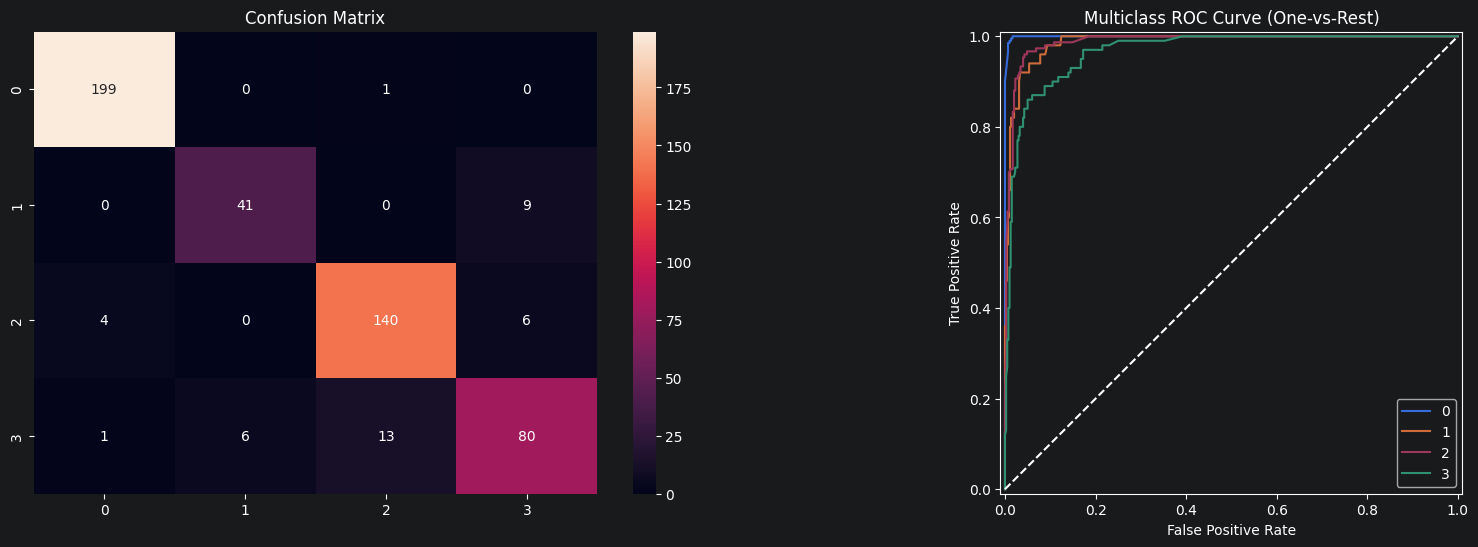

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       200
           1       0.87      0.82      0.85        50
           2       0.91      0.93      0.92       150
           3       0.84      0.80      0.82       100

    accuracy                           0.92       500
   macro avg       0.90      0.89      0.89       500
weighted avg       0.92      0.92      0.92       500





In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, classification_report
import numpy as np
import warnings

# Suppress all FutureWarnings
warnings.filterwarnings("ignore")


def report(target:np.ndarray, y_proba:np.ndarray, y_pred:np.ndarray, classes:list):
    fig, ax = plt.subplots(1,2, figsize=(20, 6))
    ax = ax.flatten()

    cf_mtx = confusion_matrix(target, y_pred)
    sns.heatmap(cf_mtx, annot=True, fmt="g", ax=ax[0])
    ax[0].set_title('Confusion Matrix')

    for idx in range(len(classes)):
        fpr, tpr, thresholds = roc_curve(target == idx, y_proba[:, idx])
        roc_auc = auc(fpr, tpr)
        display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
        display.plot(ax=ax[1])

    ax[1].plot([0, 1], [0, 1], color='white', linestyle='--')
    ax[1].set_title('Multiclass ROC Curve (One-vs-Rest)')


    ax[0].set_xticklabels(classes)
    ax[0].set_yticklabels(classes)
    plt.legend(classes)
    plt.show()

    clf_r = classification_report(target, y_pred)
    print(clf_r)

classes = np.unique(y_train)
after_pred = clf.predict(X_test)
after_prob = clf.predict_proba(X_test)

before_pred = calibrated_clf.predict(X_test)
before_prob = calibrated_clf.predict_proba(X_test)

print("======== AFTER CALIBRATION ========\n")
report(y_test, after_prob, after_pred, classes)
print("====================================\n\n")

print("======== BEFORE CALIBRATION ========\n")
report(y_test, before_prob, before_pred, classes)
print("====================================\n\n")

# Prediction Uncertanity

In [38]:
import numpy as np
import torch

def calculate_uncertainties(probs_list):
    """
    Oblicza całkowitą, aleatoryczną i epistemiczną niepewność dla klasyfikacji binarnej.

    Parametry:
    - probs_list: Lista tablic/tensorów z prawdopodobieństwami z M modeli.
                  Każdy element ma kształt (n_samples,).
    """

    # Zamieniamy listę w macierz (M_models, n_samples)
    probs_matrix = np.stack(probs_list, axis=0)

    # Mała stała stabilizująca, zapobiegająca log(0)
    eps = 1e-12

    # Pomocnicza funkcja do liczenia entropii binarnej
    def binary_entropy(p):
        p = np.clip(p, eps, 1.0 - eps) # przycinanie wartości do bezpiecznego przedziału
        return -p * np.log2(p) - (1.0 - p) * np.log2(1.0 - p)

    # --- 2. Calkowita niepewność (Entropia średniej predykcji) ---
    mean_probs = np.mean(probs_matrix, axis=0)
    total_uncertainty = binary_entropy(mean_probs)

    # --- 3. Niepewność aleatoryczna (Średnia entropia poszczególnych modeli) ---
    individual_entropies = binary_entropy(probs_matrix)
    aleatoric_uncertainty = np.mean(individual_entropies, axis=0)

    # --- 4. Niepewność epistemiczna (Różnica) ---
    epistemic_uncertainty = total_uncertainty - aleatoric_uncertainty

    # Ze względu na zaokrąglenia zmiennoprzecinkowe epistemiczna może czasem spaść minimalnie poniżej 0
    epistemic_uncertainty = np.maximum(epistemic_uncertainty, 0.0)

    return total_uncertainty, epistemic_uncertainty, aleatoric_uncertainty



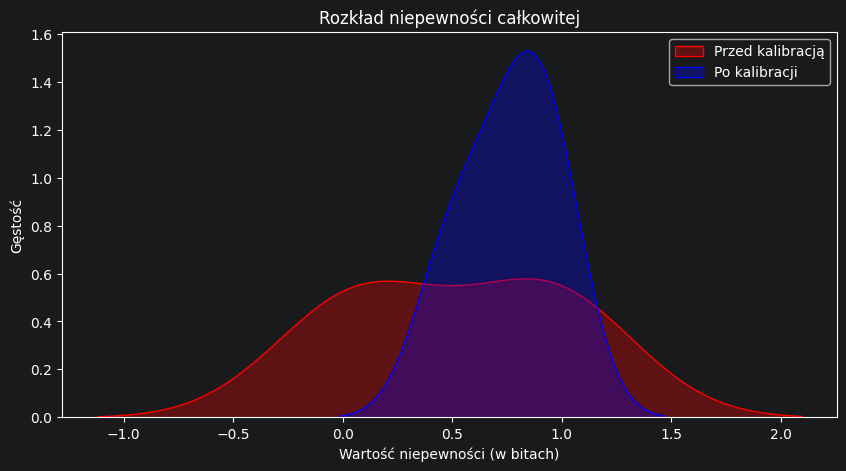

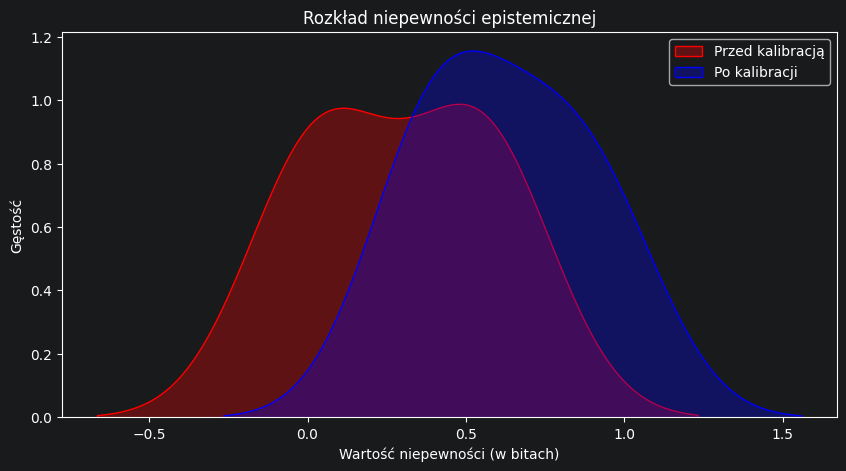

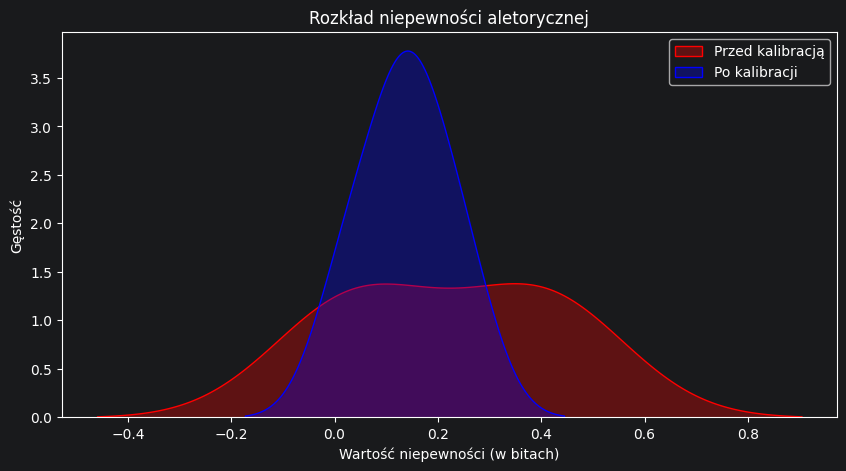

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

after_prob = clf.predict_proba(X_test)
before_prob = calibrated_clf.predict_proba(X_test)

total_bef, epistemic_bef, aleatoric_bef = calculate_uncertainties(after_prob)
total_aft, epistemic_aft, aleatoric_aft = calculate_uncertainties(before_prob)


plt.figure(figsize=(10, 5))
sns.kdeplot(total_bef, label="Przed kalibracją", color="red", fill=True, alpha=0.3)
sns.kdeplot(total_aft, label="Po kalibracji", color="blue", fill=True, alpha=0.3)
plt.title("Rozkład niepewności całkowitej")
plt.xlabel("Wartość niepewności (w bitach)")
plt.ylabel("Gęstość")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(epistemic_bef, label="Przed kalibracją", color="red", fill=True, alpha=0.3)
sns.kdeplot(epistemic_aft, label="Po kalibracji", color="blue", fill=True, alpha=0.3)
plt.title("Rozkład niepewności epistemicznej")
plt.xlabel("Wartość niepewności (w bitach)")
plt.ylabel("Gęstość")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(aleatoric_bef, label="Przed kalibracją", color="red", fill=True, alpha=0.3)
sns.kdeplot(aleatoric_aft, label="Po kalibracji", color="blue", fill=True, alpha=0.3)
plt.title("Rozkład niepewności aletorycznej")
plt.xlabel("Wartość niepewności (w bitach)")
plt.ylabel("Gęstość")
plt.legend()
plt.show()